In [1]:
import numpy as np
import matplotlib.pyplot as plt
from metrics import truthfulness, cognitive_dissonance

No handles with labels found to put in legend.


Text(0, 0.5, 'Truthfulness, $\\tau$')

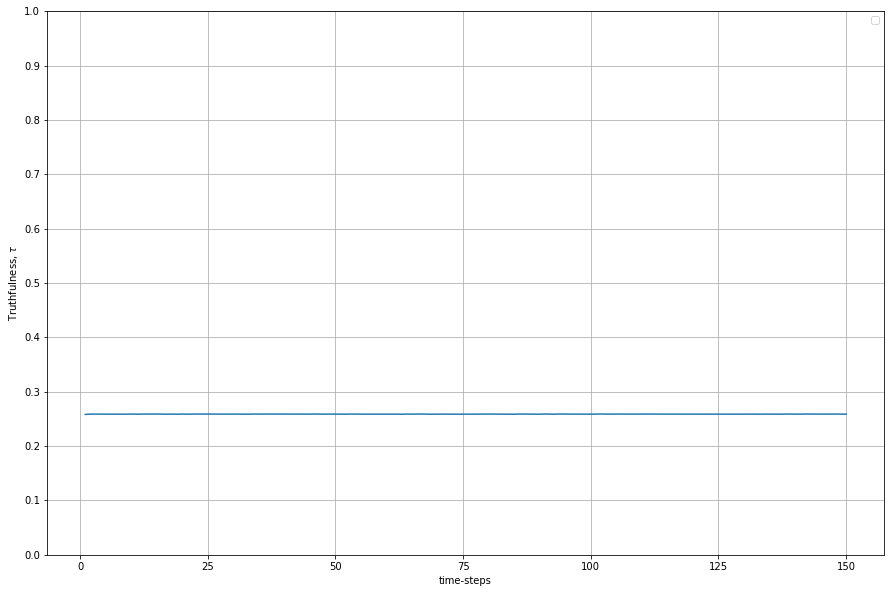

In [20]:
beliefs = np.load("1a.npz")
q_0 = beliefs["private"]
p_0 = beliefs["public"]
T_0 = truthfulness(q_0, 3)
t = np.arange(1, len(T_0))

plt.figure(figsize=(15, 10))
plt.plot(t, T_0[1::])
plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
# plt.title("Randomly chosen neighbours, no confirmation bias or conspirators")
# plt.savefig("rand_neigh")

### Random neighbours, no confirmation bias or conspirators

In [32]:
# use fixed number of neighbours
# lagre plottene
# normalising by dividing by number of neighbours
probs = np.array([0.05, 0.1, 0.2, 0.4, 1])
results = []
for prob in probs:
    beliefs = np.load(f"random_{prob}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])



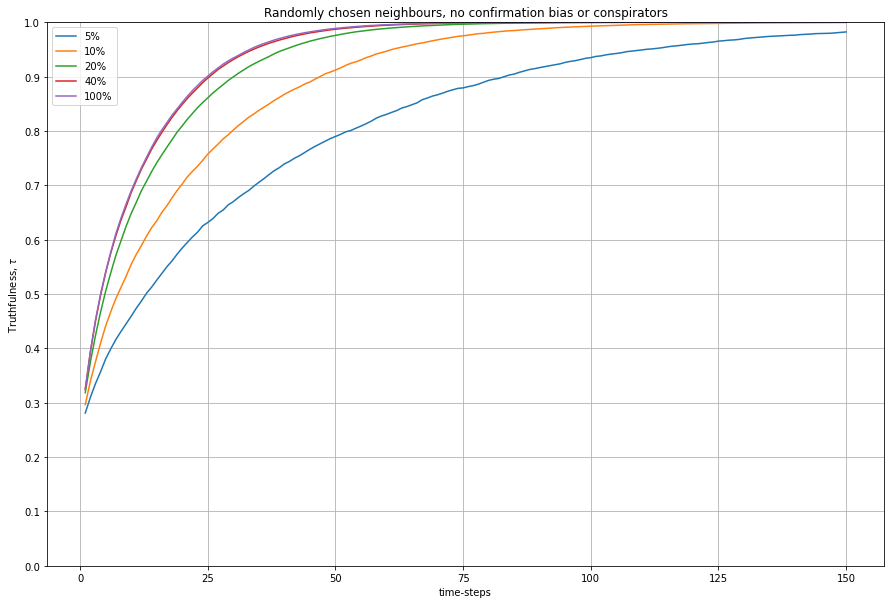

In [33]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{probs[i]*100:.0f}%")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, no confirmation bias or conspirators")
plt.savefig("rand_neigh")

In [13]:
probs = np.array([0.05, 0.1, 0.2, 0.4, 1])
results_price = []
for prob in probs:
    beliefs = np.load(f"random_{prob}_ba.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results_price.append(T_0[1::])

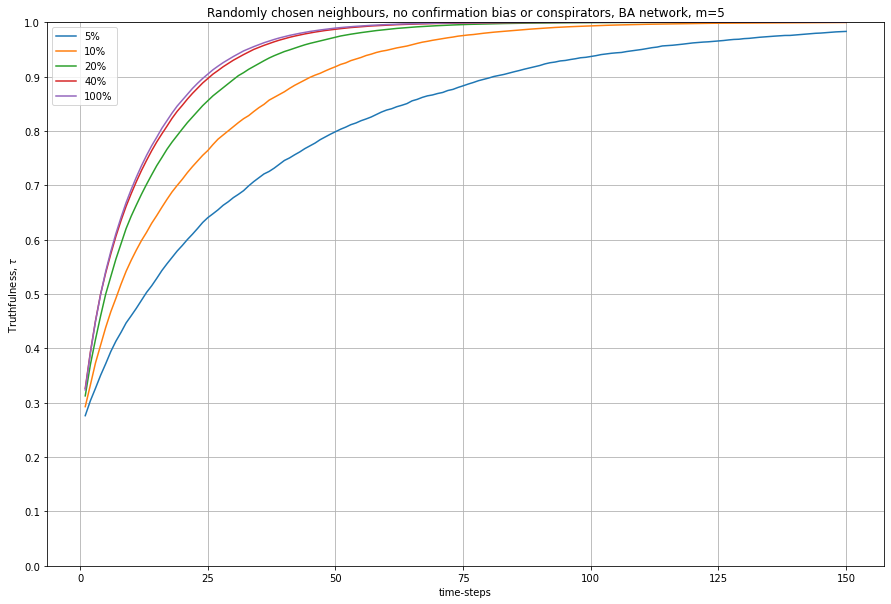

In [14]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results_price)):
    plt.plot(t, results_price[i], label=f"{probs[i]*100:.0f}%")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, no confirmation bias or conspirators, BA network, m=5")
plt.savefig("rand_neigh_ba", dpi=300)

### Random neighbours, with confirmation bias, without conspirators

In [34]:
probs = np.array([0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1])
results = []
for prob in probs:
    beliefs = np.load(f"random_CB_{prob}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])

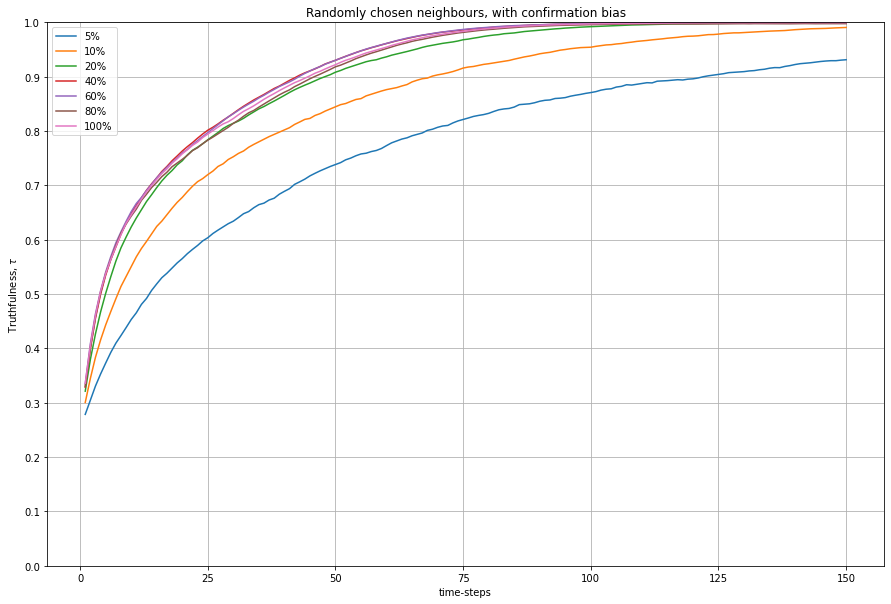

In [35]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{probs[i]*100:.0f}%")

# plt.plot(t, T_true[1::], label=r"mg$_a$=0, mg$_b$=1")
# plt.plot(t, T_consp[1::], label=r"mg$_a$=1, mg$_b$=0")
# plt.plot(t, T_2[1::], label=r"mg$_a$=1, mg$_b$=1")
plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, with confirmation bias")
plt.savefig("rand_neigh_CB", dpi=300)

In [50]:
probs = np.arange(0, 1.05, 0.05)
results = []
for prob in probs:
    beliefs = np.load(f"random_CB_{prob}_25timesteps.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::][-1])

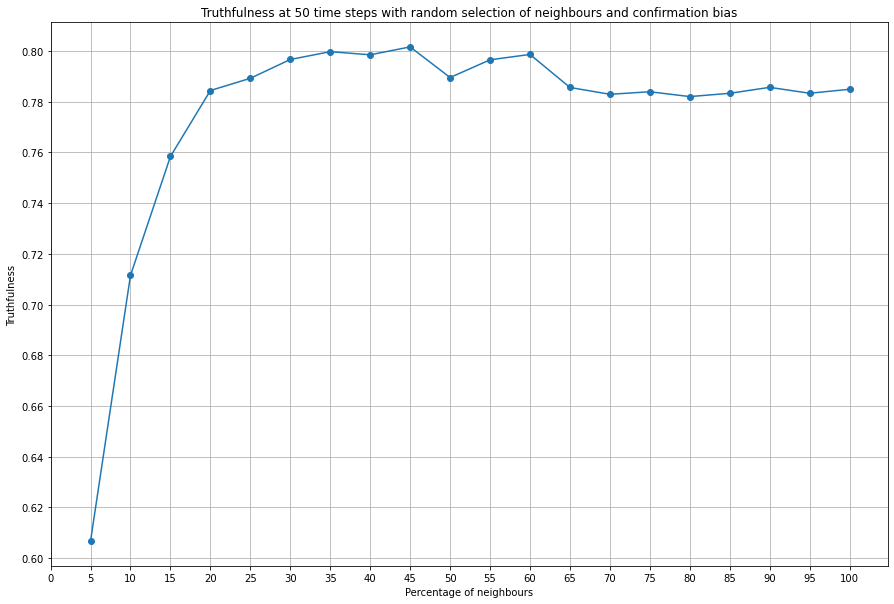

In [67]:
plt.figure(figsize=(15, 10))
plt.plot(probs[1:]*100, results[1:], '-o')
plt.grid()
plt.xticks(np.arange(0, 105, 5))
plt.yticks(np.arange(0.6, 0.82, 0.02))
plt.xlabel("Percentage of neighbours")
plt.ylabel("Truthfulness")
plt.title("Truthfulness at 50 time steps with random selection of neighbours and confirmation bias")
plt.savefig("truthfulness_CB_fraction", dpi=300)
plt.show()


### Random neighbours, with confirmation bias and conspirators

In [24]:
# run with fewer then 0.2. try 0
# few neighbours - signal dominates, not that connected to conspirators
probs = np.array([0.2, 0.4, 0.6, 0.8, 1])
results = []
for prob in probs:
    beliefs = np.load(f"random_CB_consp_{prob}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])

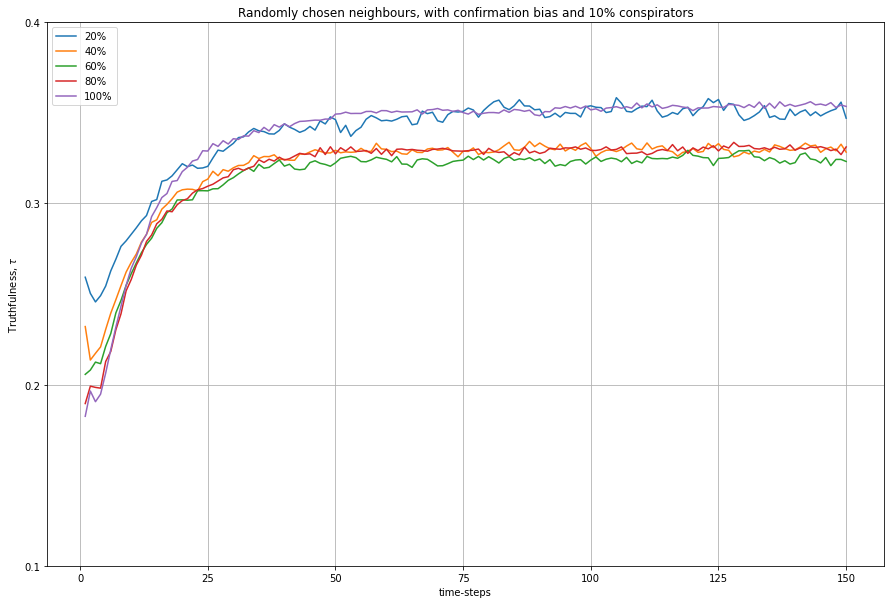

In [25]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{probs[i]*100:.0f}%")

# plt.plot(t, T_true[1::], label=r"mg$_a$=0, mg$_b$=1")
# plt.plot(t, T_consp[1::], label=r"mg$_a$=1, mg$_b$=0")
# plt.plot(t, T_2[1::], label=r"mg$_a$=1, mg$_b$=1")
plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0.1, 0.4)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, with confirmation bias and 10% conspirators")
plt.savefig("rand_neigh_CB_consp")

### Random neighbours, no confirmation bias or conspirators, fixed number of neighbours


In [18]:
num_neigh = np.array([1, 2, 3, 4, 5, 100])
results = []
for num in num_neigh:
    beliefs = np.load(f"random{num}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])



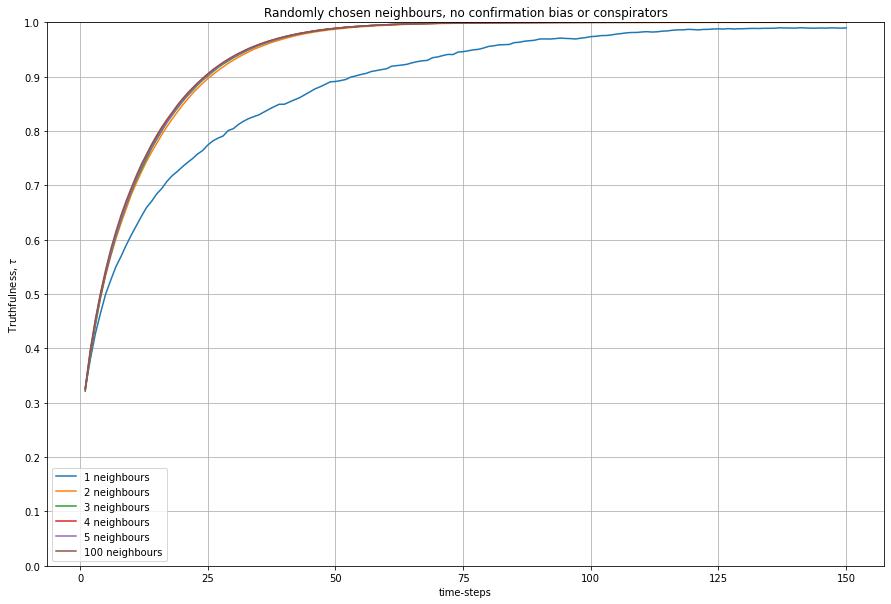

In [19]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{num_neigh[i]} neighbours")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, no confirmation bias or conspirators")
plt.savefig("rand_neigh_num")

### BA-network, fixed number

In [11]:
num_neigh = np.array([1, 2, 3, 4, 5, 100])
results = []
for num in num_neigh:
    beliefs = np.load(f"random{num}_ba.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])


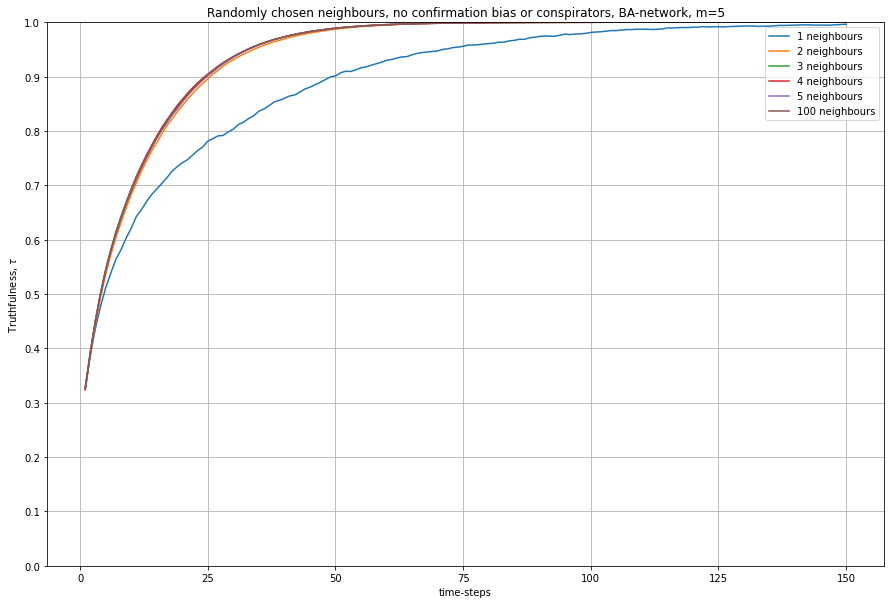

In [12]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{num_neigh[i]} neighbours")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, no confirmation bias or conspirators, BA-network, m=5")
plt.savefig("rand_neigh_num_ba")

### Fixed number of neighbours with confirmation bias

In [2]:
num_neigh = np.array([1, 2, 3, 4, 5, 100])
results = []
for num in num_neigh:
    beliefs = np.load(f"random_{num}_CB.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])


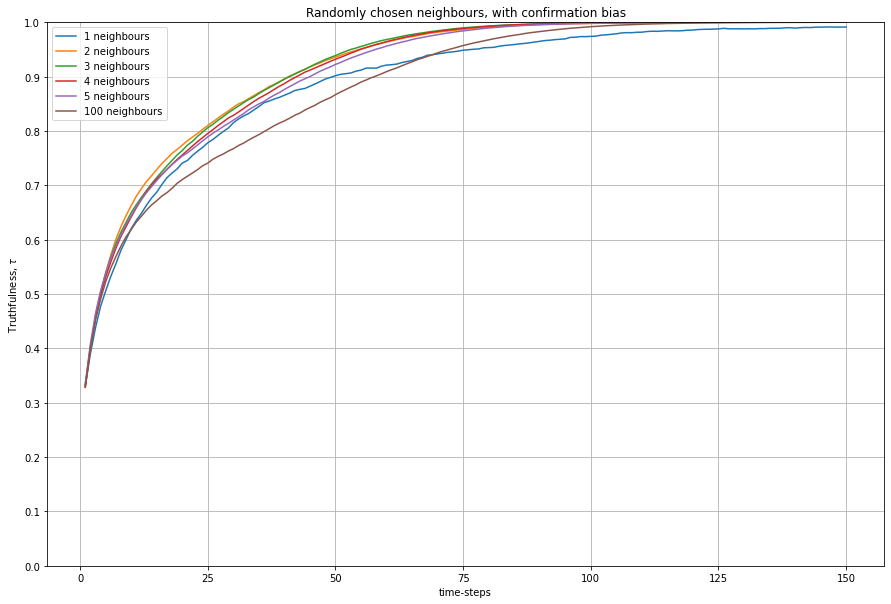

In [ ]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{num_neigh[i]} neighbours")

# plt.plot(t, T_true[1::], label=r"mg$_a$=0, mg$_b$=1")
# plt.plot(t, T_consp[1::], label=r"mg$_a$=1, mg$_b$=0")
# plt.plot(t, T_2[1::], label=r"mg$_a$=1, mg$_b$=1")
plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, with confirmation bias")
plt.savefig("rand_neigh_CB_num")

### Fixed number of neighbours with confirmation bias and conspirators

In [20]:
num_neigh = np.array([1, 2, 3, 4, 5, 100])
results = []
for num in num_neigh:
    beliefs = np.load(f"random_{num}_CB_consp.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append( T_0[1::])

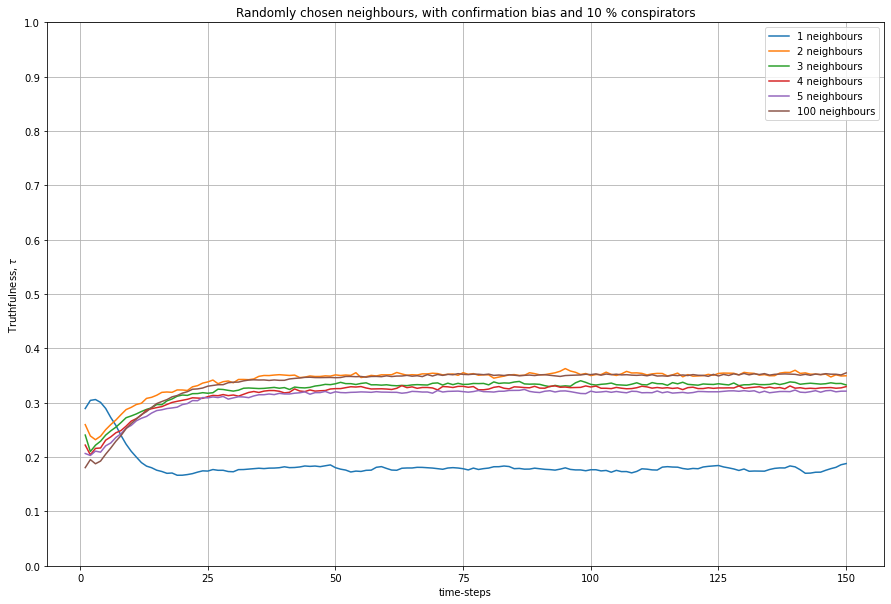

In [23]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{num_neigh[i]} neighbours")

# plt.plot(t, T_true[1::], label=r"mg$_a$=0, mg$_b$=1")
# plt.plot(t, T_consp[1::], label=r"mg$_a$=1, mg$_b$=0")
# plt.plot(t, T_2[1::], label=r"mg$_a$=1, mg$_b$=1")
plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, with confirmation bias and 10 % conspirators")
plt.savefig("rand_neigh_CB_num_consp", dpi=300)

### Cutoff

In [1]:
probs = np.array([0.05, 0.1, 0.2, 0.4, 1])
results = []
for prob in probs:
    beliefs = np.load(f"random_cutoff_{prob}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])

NameError: name 'np' is not defined

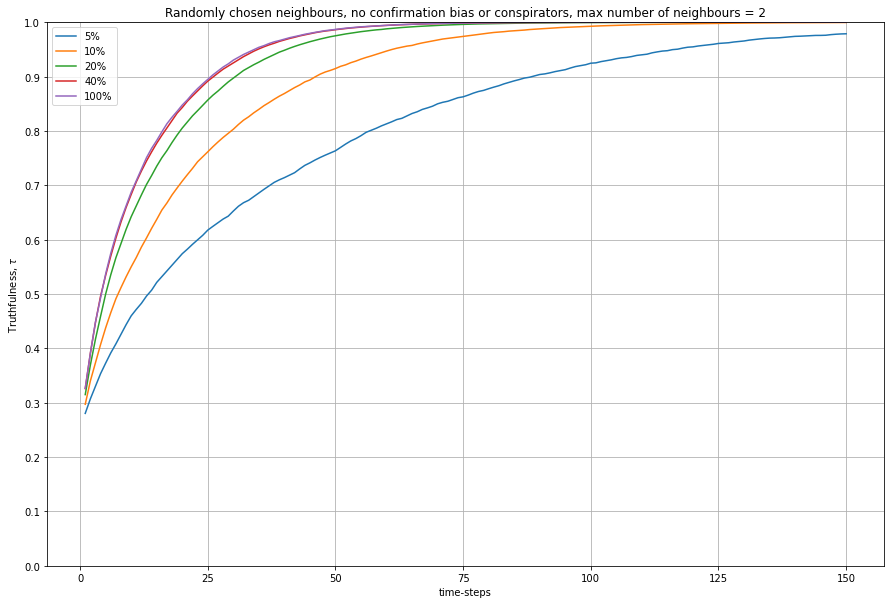

In [30]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{probs[i]*100:.0f}%")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Randomly chosen neighbours, no confirmation bias or conspirators, max number of neighbours = 2")
plt.savefig("rand_neigh_cut_2", dpi=300)

In [ ]:
# f_c = 1-1/k = 0.9 for ER network with k=10
probs = np.array([0, 0.5, 0.8, 0.9, 0.95, 0.98])
results = []
for prob in probs:
    beliefs = np.load(f"link_removal_{prob}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])

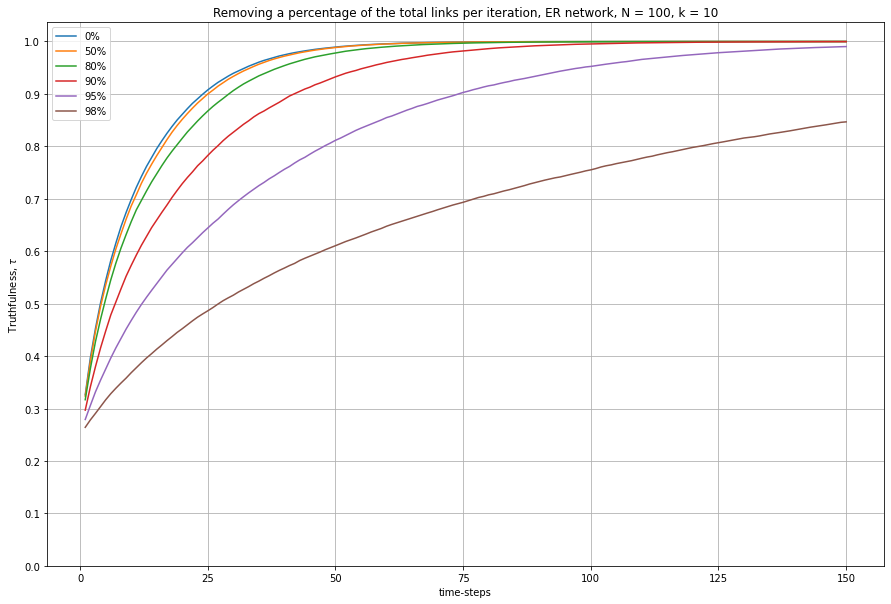

In [19]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{probs[i]*100:.0f}%")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
#plt.ylim(0.2, 0.5)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Removing a percentage of the total links per iteration, ER network, N = 100, k = 10")
plt.savefig("link_removal_ER", dpi=300)

In [20]:
probs = np.array([0, 0.5, 0.8, 0.9, 0.95, 0.98])
results = []
for prob in probs:
    beliefs = np.load(f"link_removal_BA_{prob}.npz")
    q_0 = beliefs["private"]
    p_0 = beliefs["public"]
    T_0 = truthfulness(q_0, 3)
    results.append(T_0[1::])

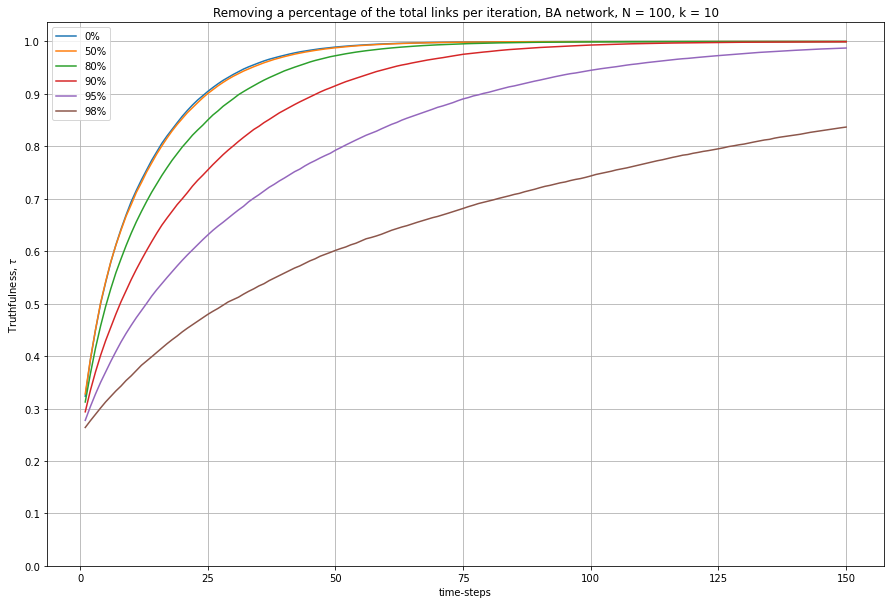

In [21]:
t = np.arange(1, len(T_0))
#print(results[0])

plt.figure(figsize=(15, 10))
for i in range(len(results)):
    plt.plot(t, results[i], label=f"{probs[i]*100:.0f}%")


plt.grid()
#plt.xlim(0, np.max(t)/2)
plt.xticks(np.arange(0, np.max(t)+1, 25))
plt.yticks(np.arange(0, 1.1, 0.1))
#plt.ylim(0.2, 0.5)
#plt.xscale("log")
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Removing a percentage of the total links per iteration, BA network, N = 100, k = 10")
plt.savefig("link_removal_BA", dpi=300)